In [ ]:
# Autoencoder with 2 LSTM layers in the Encoder (input_dim -> hidden_dim->latent_dim).
# Bidirectional laye
# Feed output of the encoder directly into the decoder.

In [182]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import umap

import os
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import random
from tqdm import tqdm

from src.data.data import get_ds, get_normalized_ds
from src.visualizations.umap_visualizer import UMAPLatent

In [183]:
class SiameseContrastiveLoss(torch.nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, data, labels):
        batch_size = data.shape[0]
        rangeset = torch.arange(batch_size)
        all_combos = torch.combinations(rangeset)
        same_labels = all_combos[(labels[all_combos[:, 0]] == labels[all_combos[:, 1]]).nonzero()].squeeze()
        opposite_labels = all_combos[(labels[all_combos[:, 0]] != labels[all_combos[:, 1]]).nonzero()].squeeze()
        same_distances = torch.linalg.norm(data[same_labels][:, 0] - data[same_labels][:, 1], dim=1)
        opposite_distances = torch.linalg.norm(data[opposite_labels][:, 0] - data[opposite_labels][:, 1], dim=1)
        same_loss = 0.5*torch.sum(same_distances.pow(2))
        opposite_loss = 0.5*torch.sum(torch.max(torch.tensor(0), self.m - opposite_distances).pow(2))
        final = same_loss + opposite_loss
        return final

In [184]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.lstm1 = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(2 * hidden_dim, latent_dim, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        x, (hidden, cell) = self.lstm1(x)
        x = self.dropout(x)
        x, (hidden, cell) = self.lstm2(x)
        return x, hidden[-1, :, :]

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.lstm1 = nn.LSTM(latent_dim, hidden_dim, batch_first=True)
        self.lstm2 = nn.LSTM(hidden_dim, output_dim, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.dropout(x)
        x, _ = self.lstm2(x)
        return x

In [185]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, output_dim):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, output_dim)
        
    def forward(self, x):
        x, embeddings = self.encoder(x)
        x = self.decoder(x)
        return x, embeddings

In [186]:
class AutoencoderTrainer(nn.Module):
    def __init__(self, model, train_ds, test_ds, variable, index_to_class, batch_size, lr, epochs):
        super(AutoencoderTrainer, self).__init__()
        self.model = model
        self.train_ds = train_ds   
        self.test_ds = test_ds
        self.variable = variable
        self.index_to_class = index_to_class
        self.batch_size = batch_size
        self.lr = lr
        self.epochs = epochs

        self.train_dataloader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        self.test_dataloader = DataLoader(test_ds, len(test_ds), shuffle=False)

        self.opt = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.reconstruction_loss_fn = nn.MSELoss()
        self.contrastive_loss_fn = SiameseContrastiveLoss(m=1.0)

        self.reconstruction_losses = []
        self.contrastive_losses = []

    def train(self):
        self.model.train()
        for epoch in tqdm(range(self.epochs)):
            for batch_idx, (data, labels) in enumerate(self.train_dataloader):
                data = data[:, :, self.variable].unsqueeze(2).float()
                self.opt.zero_grad()
                output, embeddings = self.model(data)
                reconstruction_loss = self.reconstruction_loss_fn(output, data)
                contrastive_loss = self.contrastive_loss_fn(embeddings, labels)
                loss = (1.0)*reconstruction_loss + (0.05)*contrastive_loss
                loss.backward()
                self.opt.step()
            self.reconstruction_losses.append(reconstruction_loss.item())
            self.contrastive_losses.append(contrastive_loss.item())

    def plot_losses(self):
        plt.figure()
        plt.plot(self.reconstruction_losses, label="Reconstruction Loss")
        plt.plot(self.contrastive_losses, label="Contrastive Loss")
        plt.title('Losses vs Epoch')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

    def plot_reconstruction_losses(self):
        plt.figure()
        plt.plot(self.reconstruction_losses, label="Reconstruction Loss")
        plt.title('Losses vs Epoch')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

    def plot_latent_space(self):
        for data_matrix, labels in self.test_dataloader:
            plt.figure()
            inp = data_matrix[:, :, self.variable].unsqueeze(2).float()
            with torch.no_grad():
                _, embeddings = self.model(inp)

                reducer = umap.UMAP()
                embeddings_2d = reducer.fit_transform(embeddings)

                string_labels = np.array([self.index_to_class[float(label)] for label in labels])
                unique_labels = ["Standing", "Walking", "Running", "Badminton"]

                handles, lbls = [], []
                for label in unique_labels:
                    idx = np.where(string_labels == label)[0]
                    scatter = plt.scatter(embeddings_2d[idx, 0], embeddings_2d[idx, 1], label=label)
                    handles.append(scatter)
                    lbls.append(label)
                    
                plt.legend(handles, lbls)
                plt.title("Latent Space for Variable " + str(self.variable + 1))
                plt.show()

    def plot_basicmotions_reconstructions(self):
        self.model.eval()
        for data_matrix, labels in self.test_dataloader:
            inp = data_matrix[:, :, self.variable].unsqueeze(2).float()
            with torch.no_grad():
                output, _ = self.model(inp)
                plt.figure()
                index = random.randint(0, 9)
                p1 = inp[index, :, :].squeeze()
                p2 = output[index, :, :]

                plt.title("Standing")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.figure()
                index = random.randint(10, 19)
                p1 = inp[index, :, :].squeeze()
                p2 = output[index, :, :]

                plt.title("Running")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.figure()
                index = random.randint(20, 29)
                p1 = inp[index, :, :].squeeze()
                p2 = output[index, :, :]

                plt.title("Walking")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.figure()
                index = random.randint(30, 39)
                p1 = inp[index, :, :].squeeze()
                p2 = output[index, :, :]


                plt.title("Badminton")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.show()

    

In [187]:
# Load in BasicMotions dataset
class_to_index={"standing":0, "running":1, "walking":2,"badminton":3}
index_to_class = {0:"Standing", 1:"Running", 2:"Walking", 3:"Badminton", 4:"Prototype"}

train_ds, test_ds = get_normalized_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/basicmotions/BasicMotions_TRAIN.ts", class_to_index), get_normalized_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/basicmotions/BasicMotions_TEST.ts", class_to_index)
len(train_ds)

40

In [188]:
autoencoder = Autoencoder(
    input_dim=1,
    hidden_dim=128,
    latent_dim=32,
    output_dim=1,
)
autoencoder_trainer = AutoencoderTrainer(
    model=autoencoder,
    train_ds=train_ds,
    test_ds=test_ds,
    variable=0,
    index_to_class=index_to_class,
    batch_size=40,
    lr=0.0001,
    epochs=1000
)

In [189]:
autoencoder_trainer.train()

100%|██████████| 1000/1000 [03:36<00:00,  4.62it/s]


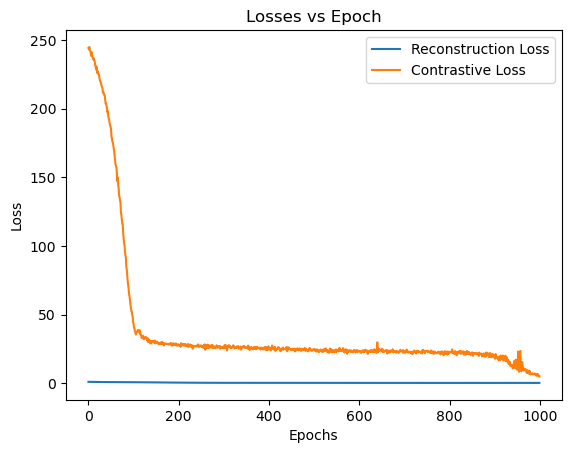

In [190]:
autoencoder_trainer.plot_losses()

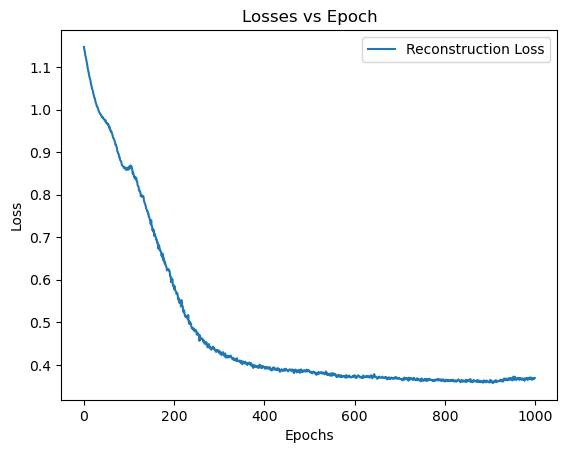

In [191]:
autoencoder_trainer.plot_reconstruction_losses()

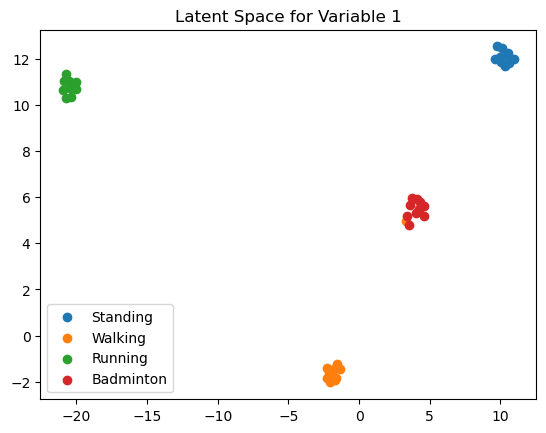

In [192]:
autoencoder_trainer.plot_latent_space()

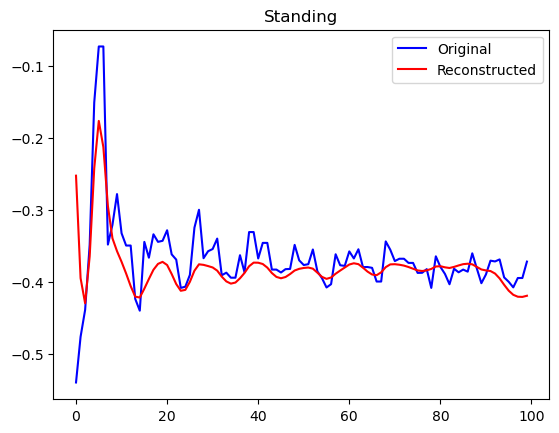

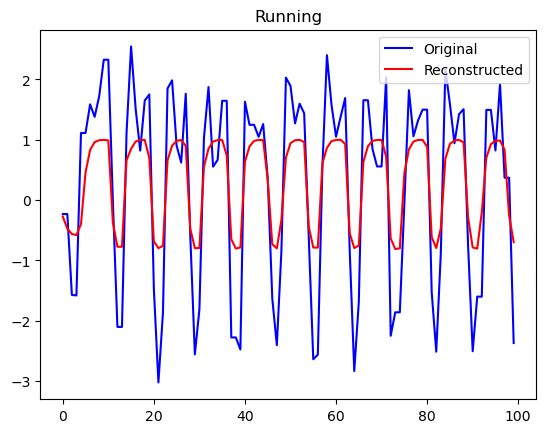

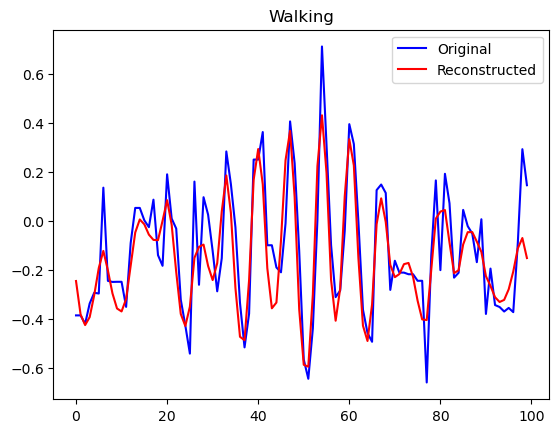

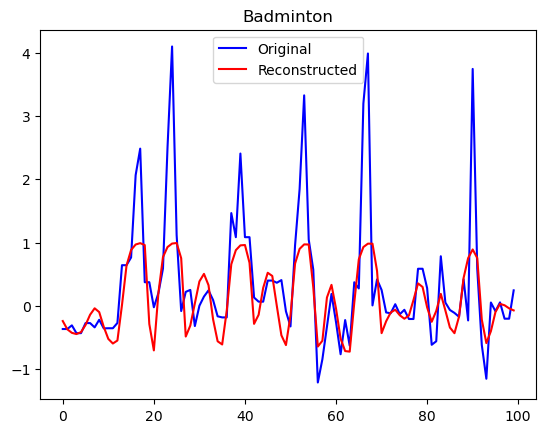

In [193]:
autoencoder_trainer.plot_basicmotions_reconstructions()